# Big Data project -> Steam Games Revies

### Proposal

I'd like to propose a possible project for the Big Data exam, I'd like to mix 2 kaggle datasets:
- https://www.kaggle.com/datasets/kieranpoc/steam-reviews
- https://www.kaggle.com/datasets/crainbramp/steam-dataset-2025-multi-modal-gaming-analytics

The proposal will analyse all reviews (data retrieved from the first dataset) and join them with games and genres (which are taken, instead, from the second dataset) in order to calculate the average hours played for positive vs negative reviews, broken down by genre. If the proposal is not hard enough I'm open to possible complications.


### Datasets

Review dataset columns structure:

recommendationid,appid,game,author_steamid,author_num_games_owned,author_num_reviews,author_playtime_forever,author_playtime_last_two_weeks,author_playtime_at_review,author_last_played,language,review,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,steam_purchase,received_for_free,written_during_early_access,hidden_in_steam_china,steam_china_location

It will be reduced to:
recommendationid[0], appid[1], game[2], author_steamid[3], review[11], weighted_vote_score[17]

App dataset column structure:

appid,name,type,is_free,release_date,required_age,short_description,supported_languages,header_image,background,metacritic_score,recommendations_total,mat_supports_windows,mat_supports_mac,mat_supports_linux,mat_initial_price,mat_final_price,mat_discount_percent,mat_currency,mat_achievement_count,mat_pc_os_min,mat_pc_processor_min,mat_pc_memory_min,mat_pc_graphics_min,mat_pc_os_rec,mat_pc_processor_rec,mat_pc_memory_rec,mat_pc_graphics_rec,created_at,updated_at

reduced to:

appid[0], name[1], type[2]

Genre dataset column structure:

id, genre

### Performance benchmarks setup

In [1]:
import time
import psutil
import json
from datetime import datetime
from typing import Dict, Any, List
import matplotlib.pyplot as plt
import pandas as pd

class PerformanceMonitor:
    """Monitor and track Spark job performance metrics"""
    
    def __init__(self):
        self.metrics = []
        self.current_operation = None
        self.start_time = None
        self.start_memory = None
        
    def start(self, operation_name: str):
        """Start monitoring an operation"""
        self.current_operation = operation_name
        self.start_time = time.time()
        self.start_memory = psutil.Process().memory_info().rss / 1024 / 1024  # MB
        print(f"\n{'='*80}")
        print(f"Starting: {operation_name}")
        print(f"{'='*80}")
        
    def end(self, spark_context=None, record_count: int = None, additional_metrics: Dict = None):
        """End monitoring and record metrics"""
        if not self.current_operation:
            return
            
        end_time = time.time()
        end_memory = psutil.Process().memory_info().rss / 1024 / 1024  # MB
        duration = end_time - self.start_time
        memory_delta = end_memory - self.start_memory
        
        metric = {
            'operation': self.current_operation,
            'duration_seconds': duration,
            'start_memory_mb': self.start_memory,
            'end_memory_mb': end_memory,
            'memory_delta_mb': memory_delta,
            'timestamp': datetime.now().isoformat(),
            'record_count': record_count
        }
        
        # Add Spark-specific metrics if available
        if spark_context:
            try:
                status = spark_context.statusTracker()
                metric['active_jobs'] = len(status.getActiveJobIds())
                metric['active_stages'] = len(status.getActiveStageIds())
            except:
                pass
        
        # Add any additional custom metrics
        if additional_metrics:
            metric.update(additional_metrics)
        
        self.metrics.append(metric)
        
        print(f"Completed: {self.current_operation}")
        print(f"Duration: {duration:.2f}s")
        print(f"Memory Delta: {memory_delta:+.2f} MB")
        if record_count:
            print(f"Records Processed: {record_count:,}")
            print(f"Throughput: {record_count/duration:,.0f} records/sec")
        print(f"{'='*80}\n")
        
        self.current_operation = None
        
    def get_summary(self) -> pd.DataFrame:
        """Get summary of all metrics as DataFrame"""
        return pd.DataFrame(self.metrics)
    
    def plot_performance(self):
        """Create performance visualization"""
        if not self.metrics:
            print("No metrics to plot")
            return
            
        df = pd.DataFrame(self.metrics)
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        fig.suptitle('Spark Performance Metrics', fontsize=16, fontweight='bold')
        
        # Execution time comparison
        axes[0, 0].barh(df['operation'], df['duration_seconds'], color='steelblue')
        axes[0, 0].set_xlabel('Duration (seconds)')
        axes[0, 0].set_title('Execution Time by Operation')
        axes[0, 0].grid(axis='x', alpha=0.3)
        
        # Memory usage
        axes[0, 1].barh(df['operation'], df['memory_delta_mb'], color='coral')
        axes[0, 1].set_xlabel('Memory Delta (MB)')
        axes[0, 1].set_title('Memory Impact by Operation')
        axes[0, 1].grid(axis='x', alpha=0.3)
        
        # Records processed (if available)
        df_with_counts = df[df['record_count'].notna()]
        if not df_with_counts.empty:
            axes[1, 0].barh(df_with_counts['operation'], df_with_counts['record_count'], color='mediumseagreen')
            axes[1, 0].set_xlabel('Records Processed')
            axes[1, 0].set_title('Data Volume by Operation')
            axes[1, 0].grid(axis='x', alpha=0.3)
        
        # Throughput (records/sec)
        df_with_counts['throughput'] = df_with_counts['record_count'] / df_with_counts['duration_seconds']
        if not df_with_counts.empty:
            axes[1, 1].barh(df_with_counts['operation'], df_with_counts['throughput'], color='mediumpurple')
            axes[1, 1].set_xlabel('Throughput (records/sec)')
            axes[1, 1].set_title('Processing Throughput')
            axes[1, 1].grid(axis='x', alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def save_report(self, filename='performance_report.json'):
        """Save metrics to JSON file"""
        with open(filename, 'w') as f:
            json.dump(self.metrics, f, indent=2)
        print(f"Performance report saved to {filename}")

# Initialize performance monitor
perf = PerformanceMonitor()
print("Performance monitoring initialized!")

Performance monitoring initialized!


### Dataset loading

In [2]:
reviewFilePath = 'datasets/small_reviews.csv'
applicationFilePath = 'datasets/sample_apps.csv'
genreFilePath = 'datasets/genres.csv'
genreByAppFilePath = 'datasets/application_genres_standardized.csv'

In [3]:
from pyspark.sql import SparkSession

In [4]:
perf.start("Spark Session Initialization")

spark = SparkSession.builder \
    .master("local[4]") \
    .appName("Local Spark with Benchmarks") \
    .config('spark.ui.port', '4040') \
    .config('spark.sql.shuffle.partitions', '200') \
    .getOrCreate()
sc = spark.sparkContext

sc.setLogLevel("WARN")

perf.end(sc)


Starting: Spark Session Initialization
Completed: Spark Session Initialization
Duration: 3.27s
Memory Delta: +0.62 MB



In [5]:
from typing import Optional, Tuple
from pyspark.sql import Row

class SteamParser:

    @staticmethod
    def parse_application_line(row) -> Optional[Tuple[int, str, int, int]]:
        try:
            parts = list(row)
            
            appid = int(parts[0]) if parts[0] else 0
            name = parts[1] if parts[1] else ""
            metacritic = int(parts[10]) if parts[10] else 0
            recommendations = int(parts[11]) if parts[11] else 0
            
            return (appid, name, metacritic, recommendations)
        except Exception as e:
            return None

    @staticmethod
    def parse_review_line(row) -> Optional[Tuple[int, bool, float, float, float]]:
        try:
            parts = list(row)
            
            appid = int(parts[1].strip())
            playtime_forever = float(parts[6].strip()) if parts[6].strip() else 0.0
            playtime_at_review = float(parts[8].strip()) if parts[8].strip() else 0.0
            voted_up_str = parts[14].strip().lower()
            voted_up = True if voted_up_str in ('true', '1', 'yes') else False
            weight_vote_score = float(parts[17].strip())
            # Filter invalid data
            if playtime_at_review < 0:
                return None
            return (appid, voted_up, playtime_forever, playtime_at_review, weight_vote_score)
        except:
            return None

    @staticmethod
    def parse_genre_line(row) -> Optional[Tuple[int, str]]:
        try:
            parts = list(row)
            
            genre_id = int(parts[0].strip())
            genre_name = parts[1].strip()
            
            if not genre_name:
                return None
            return (genre_id, genre_name)
        except:
            return None

    @staticmethod
    def parse_app_genre_line(row) -> Optional[Tuple[int, int]]:
        try:
            parts = list(row)

            appid = int(parts[0].strip())
            genre_id = int(parts[1].strip())
            return (appid, genre_id)
        except:
            return None

In [6]:
# Games parsing
perf.start("Load and Parse Games")

df = spark.read.csv(
    applicationFilePath,
    header=True,  # if your CSV has headers
    quote='"',
    escape='"',
    multiLine=True  # handles newlines within quoted fields
)

rddGames = df.rdd \
    .map(lambda row: SteamParser.parse_application_line(row)) \
    .filter(lambda x: x is not None)

perf.end(sc, rddGames.count(), {'data_source': 'rddGames'})

# Reviews parsing
perf.start("Load and Parse Reviews")

df = spark.read.csv(
    reviewFilePath,
    header=True,  # if your CSV has headers
    quote='"',
    escape='"',
    multiLine=True  # handles newlines within quoted fields
)

rddReviews = df.rdd \
    .map(lambda row: SteamParser.parse_review_line(row)) \
    .filter(lambda x: x is not None)

perf.end(sc, rddReviews.count(), {'data_source': 'rddReviews'})

# Genres parsing
perf.start("Load and Parse Genres")

df = spark.read.csv(
    genreFilePath,
    header=True,  # if your CSV has headers
    quote='"',
    escape='"',
    multiLine=True  # handles newlines within quoted fields
)

rddGenres = df.rdd \
    .map(lambda row: SteamParser.parse_genre_line(row)) \
    .filter(lambda x: x is not None)

perf.end(sc, rddGenres.count(), {'data_source': 'rddGenres'})

# Genres by App parsing
perf.start("Load and Parse Genres by App")

df = spark.read.csv(
    genreByAppFilePath,
    header=True,  # if your CSV has headers
    quote='"',
    escape='"',
    multiLine=True  # handles newlines within quoted fields
)

rddGenresByApp = df.rdd \
    .map(lambda row: SteamParser.parse_app_genre_line(row)) \
    .filter(lambda x: x is not None)

perf.end(sc, rddGenresByApp.count(), {'data_source': 'rddGenresByApp'})


Starting: Load and Parse Games
Completed: Load and Parse Games
Duration: 4.05s
Memory Delta: +0.50 MB
Records Processed: 12,070
Throughput: 2,982 records/sec


Starting: Load and Parse Reviews
Completed: Load and Parse Reviews
Duration: 1.23s
Memory Delta: +0.12 MB
Records Processed: 28,813
Throughput: 23,519 records/sec


Starting: Load and Parse Genres
Completed: Load and Parse Genres
Duration: 0.18s
Memory Delta: +0.00 MB
Records Processed: 33
Throughput: 181 records/sec


Starting: Load and Parse Genres by App
Completed: Load and Parse Genres by App
Duration: 1.44s
Memory Delta: +0.00 MB
Records Processed: 587,484
Throughput: 408,691 records/sec



### Dataset exploration

In [7]:
print(rddReviews.first() if rddReviews else "")
print(rddGames.first() if rddGames else "")
print(rddGenres.first() if rddGenres else "")
print(rddGenresByApp.first() if rddGenresByApp else "")

(10, True, 4653.0, 4650.0, 0.0)
(3460, 'Talismania Deluxe', 0, 0)
(1, '360 Video')
(10, 3)


### Execution

In [8]:
num_partitions = 8

In [9]:
# rddGames = rddGames.repartition(num_partitions).cache()
# rddReviews = rddReviews.repartition(num_partitions).cache()
# rddGenres = rddGenres.cache()  # Small dataset, keep cached
# rddGenresByApp = rddGenresByApp.repartition(num_partitions).cache()

In [9]:
# Aggregate: sum of weighted playtime and sum of weights
def aggregate_weighted_playtime(acc, value):
    """Accumulator function for weighted average calculation"""
    playtime, weight = value
    weighted_playtime = playtime * weight
    return (acc[0] + weighted_playtime, acc[1] + weight, acc[2] + 1)

def combine_aggregates(acc1, acc2):
    """Combiner function for weighted average calculation"""
    return (acc1[0] + acc2[0], acc1[1] + acc2[1], acc1[2] + acc2[2])

In [10]:
perf.start("RDD repartitioning")

# Only repartition if needed for joins, and do it on the key-value pairs
# Games: (appid, (name, metacritic, recommendations))
games_kv = rddGames.map(lambda x: (x[0], (x[1], x[2], x[3]))) \
    .partitionBy(num_partitions) \
    .cache()

# Reviews: (appid, (voted_up, playtime_at_review, weight_vote_score))
reviews_kv = rddReviews.map(lambda x: (x[0], (x[1], x[3], x[4]))) \
    .partitionBy(num_partitions) \
    .cache()

# GenresByApp: (appid, genre_id)
genres_by_app_kv = rddGenresByApp.map(lambda x: (x[0], x[1])) \
    .partitionBy(num_partitions) \
    .cache()

# Genres: small dataset, no need to partition
genres_kv = rddGenres.map(lambda x: (x[0], x[1])).cache()

perf.end(sc)


Starting: RDD repartitioning
Completed: RDD repartitioning
Duration: 0.06s
Memory Delta: +0.00 MB



In [11]:
perf.start("Compute Average Hours by Genre and Sentiment")

reviews_with_genre_id = reviews_kv.join(genres_by_app_kv)

reviews_by_genre_id = reviews_with_genre_id.map(
    lambda x: (x[1][1], (x[1][0][0], x[1][0][1], x[1][0][2]))
)

reviews_with_genre_name = reviews_by_genre_id.join(genres_kv)

genre_sentiment_pairs = reviews_with_genre_name.map(
    lambda x: ((x[1][1], x[1][0][0]), (x[1][0][1], x[1][0][2]))
)

aggregated = genre_sentiment_pairs \
    .mapValues(lambda v: (v[0] * v[1], v[1], 1)) \
    .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1], a[2] + b[2]))

results = aggregated.map(
    lambda x: (
        x[0][0],  # genre_name
        "Positive" if x[0][1] else "Negative",  # sentiment
        x[1][0] / x[1][1] if x[1][1] > 0 else 0.0,  # weighted_avg_hours
        x[1][2]  # review_count
    )
)

sorted_results = results.sortBy(lambda x: (x[0], x[1]))

# Collect results
final_results = sorted_results.collect()

perf.end(sc, len(final_results), {'aggregation_type': 'average_by_genre_sentiment'})


Starting: Compute Average Hours by Genre and Sentiment
Completed: Compute Average Hours by Genre and Sentiment
Duration: 3.91s
Memory Delta: +0.00 MB
Records Processed: 54
Throughput: 14 records/sec



In [12]:
print("\n" + "="*80)
print("AVERAGE HOURS PLAYED: POSITIVE VS NEGATIVE REVIEWS BY GENRE")
print("="*80)
print(f"{'Genre':<30} {'Sentiment':<12} {'Avg Hours':<15} {'Review Count':<15}")
print("-"*80)

for genre, sentiment, avg_hours, count in final_results:
    print(f"{genre:<30} {sentiment:<12} {avg_hours:<15.2f} {count:<15,}")

print("="*80)


AVERAGE HOURS PLAYED: POSITIVE VS NEGATIVE REVIEWS BY GENRE
Genre                          Sentiment    Avg Hours       Review Count   
--------------------------------------------------------------------------------
Action                         Negative     8634.85         2,927          
Action                         Positive     8827.51         15,688         
Adventure                      Negative     6482.22         1,810          
Adventure                      Positive     5568.65         9,486          
Animation & Modeling           Negative     661.21          13             
Animation & Modeling           Positive     8615.48         216            
Audio Production               Negative     460.00          2              
Audio Production               Positive     6862.46         17             
Casual                         Negative     8286.78         531            
Casual                         Positive     4908.03         3,641          
Design & Illustration 

In [31]:
perf.start("Generate Genre Comparison Analysis")

genre_comparison = {}
for genre, sentiment, avg_hours, count in final_results:
    if genre not in genre_comparison:
        genre_comparison[genre] = {}
    genre_comparison[genre][sentiment] = {"avg_hours": avg_hours, "count": count}

print("\n" + "="*106)
print("GENRE COMPARISON: POSITIVE VS NEGATIVE REVIEW HOURS")
print("="*106)
print(f"{'Genre':<30} {'Pos Hrs':<12} {'Neg Hrs':<12} {'Difference':<15} {'Total Reviews':<15} {'Overall Sentiment':<20}")
print("-"*106)

comparison_results = []
for genre, data in genre_comparison.items():
    pos_hours = data.get("Positive", {}).get("avg_hours", 0)
    neg_hours = data.get("Negative", {}).get("avg_hours", 0)
    pos_count = data.get("Positive", {}).get("count", 0)
    neg_count = data.get("Negative", {}).get("count", 0)
    difference = pos_hours - neg_hours
    total_reviews = pos_count + neg_count
    
    comparison_results.append((genre, pos_hours, neg_hours, difference, total_reviews))

# Sort by difference (descending)
comparison_results.sort(key=lambda x: x[3], reverse=True)

perf.end(sc, len(comparison_results), {'analysis_type': 'genre_comparison'})

for genre, pos_hrs, neg_hrs, diff, total in comparison_results:
    sentiment = 'Positive' if diff > 0 else 'Negative' if diff < 0 else 'Neutral'
    print(f"{genre:<30} {pos_hrs:<12.2f} {neg_hrs:<12.2f} {diff:<+15.2f} {total:<15,} {sentiment: <20}")

print("="*106)


Starting: Generate Genre Comparison Analysis

GENRE COMPARISON: POSITIVE VS NEGATIVE REVIEW HOURS
Genre                          Pos Hrs      Neg Hrs      Difference      Total Reviews   Overall Sentiment   
----------------------------------------------------------------------------------------------------------
Completed: Generate Genre Comparison Analysis
Duration: 0.00s
Memory Delta: +0.00 MB
Records Processed: 29
Throughput: 12,379 records/sec

Video Production               19623.03     981.61       +18641.41       42              Positive            
Animation & Modeling           8615.48      661.21       +7954.27        229             Positive            
Audio Production               6862.46      460.00       +6402.46        19              Positive            
Design & Illustration          5857.42      486.97       +5370.45        227             Positive            
Racing                         5948.11      1645.77      +4302.34        757             Positive        

In [32]:
perf.start("Sentiment by Playtime Bracket Analysis")

# Analyze sentiment patterns across different playtime brackets
def categorize_playtime(hours):
    if hours < 2:
        return "000-0h (Refund Window)"
    elif hours < 10:
        return "002-10h (Early Game)"
    elif hours < 50:
        return "010-50h (Mid Game)"
    elif hours < 200:
        return "050-200h (Committed)"
    else:
        return "200+h (Hardcore)"

playtime_sentiment = reviews_kv.map(
    lambda x: (categorize_playtime(x[1][1]), (1 if x[1][0] else 0, 1))
).reduceByKey(
    lambda a, b: (a[0] + b[0], a[1] + b[1])
).map(
    lambda x: (x[0], x[1][0] / x[1][1] * 100, x[1][1])  # (bracket, % positive, count)
).sortBy(lambda x: x[0])

bracket_results = playtime_sentiment.collect()

perf.end(sc, len(bracket_results), {'analysis_type': 'playtime_brackets'})

print("\n" + "="*80)
print("SENTIMENT BY PLAYTIME BRACKET")
print("="*80)
print(f"{'Playtime Bracket':<30} {'% Positive':<15} {'Review Count':<15}")
print("-"*80)
for bracket, pct_positive, count in bracket_results:
    print(f"{bracket:<30} {pct_positive:<15.2f} {count:<15,}")
print("="*80)


Starting: Sentiment by Playtime Bracket Analysis
Completed: Sentiment by Playtime Bracket Analysis
Duration: 1.35s
Memory Delta: +0.00 MB
Records Processed: 5
Throughput: 4 records/sec


SENTIMENT BY PLAYTIME BRACKET
Playtime Bracket               % Positive      Review Count   
--------------------------------------------------------------------------------
000-0h (Refund Window)         71.88           480            
002-10h (Early Game)           57.44           336            
010-50h (Mid Game)             64.43           1,653          
050-200h (Committed)           78.65           3,189          
200+h (Hardcore)               88.24           23,155         


### Performance banchmark results

In [33]:
# Display performance summary
print("\n" + "="*100)
print("PERFORMANCE SUMMARY")
print("="*100)

summary_df = perf.get_summary()
print(summary_df[['operation', 'duration_seconds', 'memory_delta_mb', 'record_count']].to_string(index=False))

print("\n" + "="*100)
print("AGGREGATE STATISTICS")
print("="*100)
print(f"Total Operations: {len(summary_df)}")
print(f"Total Execution Time: {summary_df['duration_seconds'].sum():.2f} seconds")
print(f"Average Operation Time: {summary_df['duration_seconds'].mean():.2f} seconds")
print(f"Total Memory Delta: {summary_df['memory_delta_mb'].sum():.2f} MB")
print(f"Total Records Processed: {summary_df['record_count'].sum():,.0f}")
print("="*100)


PERFORMANCE SUMMARY
                                   operation  duration_seconds  memory_delta_mb  record_count
                Spark Session Initialization          0.008695              0.0           NaN
                          RDD repartitioning          0.045481              0.0           NaN
Compute Average Hours by Genre and Sentiment          6.751176              0.0          54.0
          Generate Genre Comparison Analysis          0.002343              0.0          29.0
      Sentiment by Playtime Bracket Analysis          1.345692              0.0           5.0

AGGREGATE STATISTICS
Total Operations: 5
Total Execution Time: 8.15 seconds
Average Operation Time: 1.63 seconds
Total Memory Delta: 0.00 MB
Total Records Processed: 88


/tmp/ipykernel_113/2156691594.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_with_counts['throughput'] = df_with_counts['record_count'] / df_with_counts['duration_seconds']


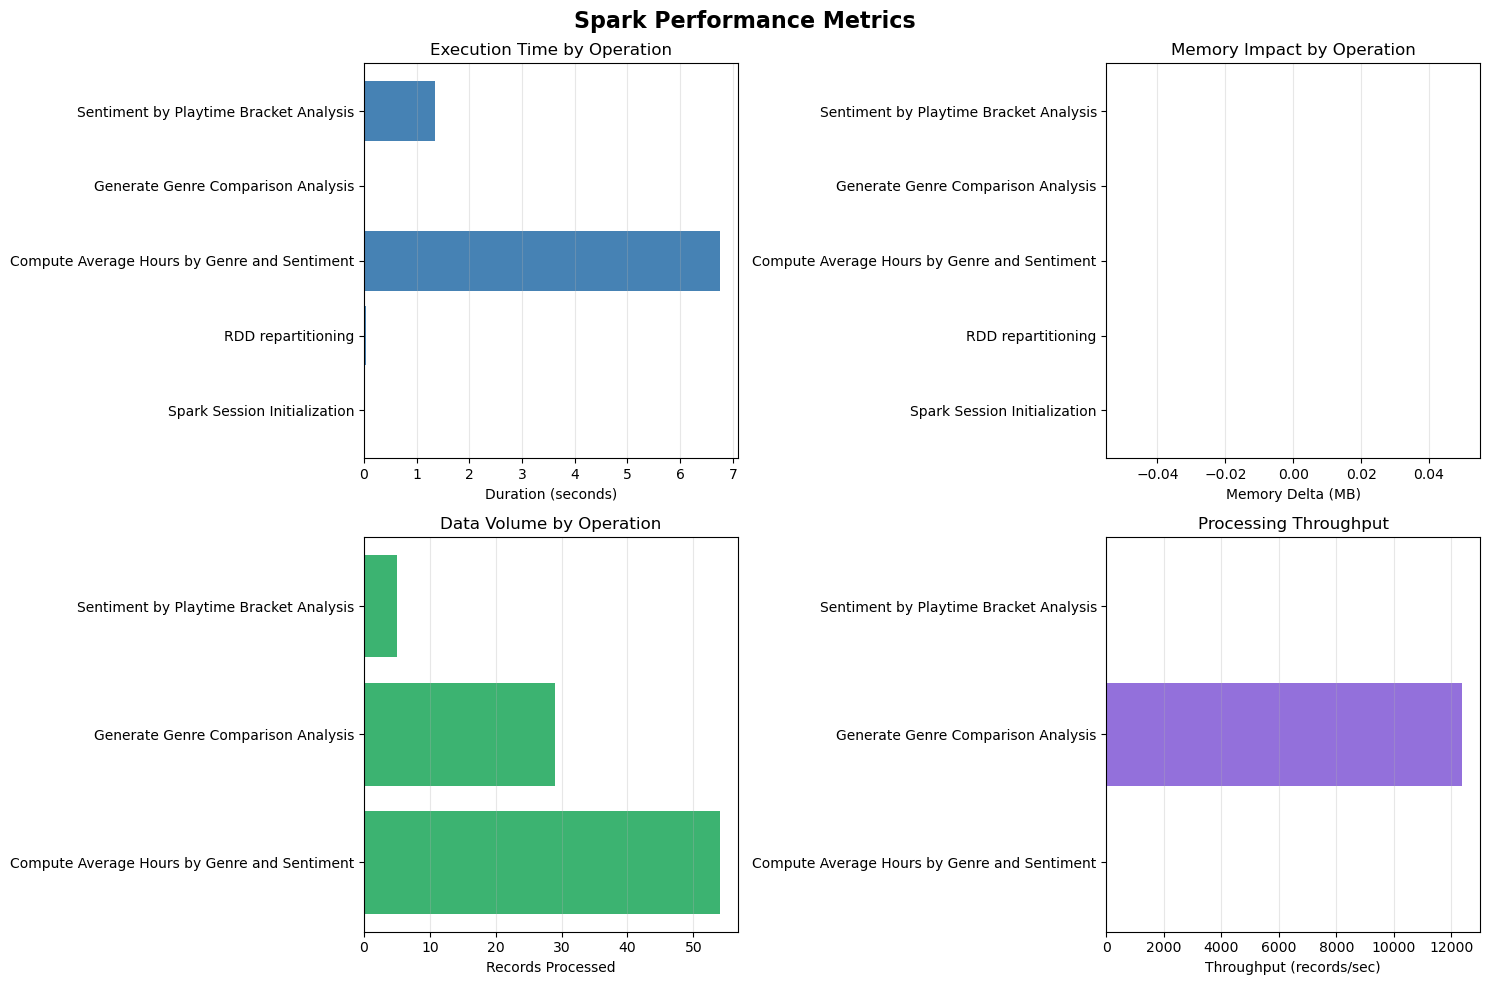

In [34]:
perf.plot_performance()

### Performance Optimization Comparison

In [35]:
# Test different partition counts
print("\n" + "="*80)
print("PARTITION COUNT OPTIMIZATION TEST")
print("="*80)

partition_counts = [4, 8, 16, 32]
partition_results = []

for num_partitions in partition_counts:
    print(f"\nTesting with {num_partitions} partitions...")
    
    start_time = time.time()
    
    # Repartition and perform a simple aggregation
    test_rdd = reviews_kv.repartition(num_partitions)
    result = test_rdd.mapValues(lambda x: 1).reduceByKey(lambda a, b: a + b).count()
    
    duration = time.time() - start_time
    partition_results.append((num_partitions, duration))
    
    print(f"Duration: {duration:.2f}s")

print("\n" + "="*80)
print(f"{'Partitions':<15} {'Duration (s)':<15} {'Speedup':<15}")
print("-"*80)
baseline = partition_results[0][1]
for parts, dur in partition_results:
    speedup = baseline / dur
    print(f"{parts:<15} {dur:<15.2f} {speedup:<15.2f}x")
print("="*80)


PARTITION COUNT OPTIMIZATION TEST

Testing with 4 partitions...
Duration: 0.53s

Testing with 8 partitions...
Duration: 0.80s

Testing with 16 partitions...
Duration: 1.39s

Testing with 32 partitions...
Duration: 2.58s

Partitions      Duration (s)    Speedup        
--------------------------------------------------------------------------------
4               0.53            1.00           x
8               0.80            0.66           x
16              1.39            0.38           x
32              2.58            0.20           x


In [36]:
# Compare with and without caching
print("\n" + "="*80)
print("CACHING IMPACT TEST")
print("="*80)

# Without cache
print("\nRunning WITHOUT cache...")
test_rdd_no_cache = reviews.map(lambda x: (x[0], x[3]))

start_time = time.time()
count1 = test_rdd_no_cache.count()
count2 = test_rdd_no_cache.count()  # Second access
time_no_cache = time.time() - start_time

print(f"Time without cache (2 operations): {time_no_cache:.2f}s")

# With cache
print("\nRunning WITH cache...")
test_rdd_cache = rddReviews.map(lambda x: (x[0], x[3])).cache()

start_time = time.time()
count1 = test_rdd_cache.count()
count2 = test_rdd_cache.count()  # Second access
time_cache = time.time() - start_time

print(f"Time with cache (2 operations): {time_cache:.2f}s")
print(f"\nSpeedup from caching: {time_no_cache/time_cache:.2f}x")
print("="*80)


CACHING IMPACT TEST

Running WITHOUT cache...


NameError: name 'reviews' is not defined

### Spark internal metrics

In [ ]:
# Get Spark execution metrics
print("\n" + "="*80)
print("SPARK EXECUTION METRICS")
print("="*80)

status = sc.statusTracker()

# print(f"Active Jobs: {len(status.getActiveJobIds())}")
print(f"Active Stages: {len(status.getActiveStageIds())}")
print(f"Default Parallelism: {sc.defaultParallelism}")

# Application metrics
print(f"\nApplication ID: {sc.applicationId}")
print(f"Spark Version: {sc.version}")
print(f"Master: {sc.master}")

print("\nAccess Spark UI for detailed metrics at: http://localhost:4040")
print("="*80)

### Save performane report

In [ ]:
# Save detailed performance report
perf.save_report('performance_report.json')

# Also save as CSV for easy analysis
summary_df = perf.get_summary()
summary_df.to_csv('performance_metrics.csv', index=False)
print("Performance metrics saved to performance_metrics.csv")

# Create a summary report
with open('performance_summary.txt', 'w') as f:
    f.write("SPARK PERFORMANCE BENCHMARK SUMMARY\n")
    f.write("="*80 + "\n\n")
    
    f.write("Configuration:\n")
    f.write(f"  Master: {sc.master}\n")
    f.write(f"  Default Parallelism: {sc.defaultParallelism}\n")
    f.write(f"  Spark Version: {sc.version}\n\n")
    
    f.write("Overall Statistics:\n")
    f.write(f"  Total Operations: {len(summary_df)}\n")
    f.write(f"  Total Execution Time: {summary_df['duration_seconds'].sum():.2f}s\n")
    f.write(f"  Average Operation Time: {summary_df['duration_seconds'].mean():.2f}s\n")
    f.write(f"  Total Records Processed: {summary_df['record_count'].sum():,.0f}\n")
    f.write(f"  Total Memory Delta: {summary_df['memory_delta_mb'].sum():.2f} MB\n\n")
    
    f.write("Top 5 Slowest Operations:\n")
    slowest = summary_df.nlargest(5, 'duration_seconds')[['operation', 'duration_seconds']]
    f.write(slowest.to_string(index=False) + "\n\n")
    
    f.write("Top 5 Memory Intensive Operations:\n")
    memory_intensive = summary_df.nlargest(5, 'memory_delta_mb')[['operation', 'memory_delta_mb']]
    f.write(memory_intensive.to_string(index=False) + "\n")

print("Performance summary saved to performance_summary.txt")
print("\nAll benchmark results saved successfully!")